# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [33]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [34]:
# TODO: Load your dataset(s) here.
# Update the path below to your actual data file.

DATA_PATH = "../data/Metro_Interstate_Traffic_Volume.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [35]:
# Verify the data loaded correctly by displaying shape and a sample

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")

df.sample(5)

Dataset shape: 48204 rows x 9 columns


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
18340,NaN,294.94,10.67,0.0,90,Thunderstorm,proximity thunderstorm,2015-09-17 10:00:00,4582
23640,NaN,290.79,10.92,0.0,90,Rain,heavy intensity rain,2016-05-26 03:00:00,356
36796,NaN,286.61,0.00,0.0,1,Haze,haze,2017-08-31 23:00:00,1576
38355,NaN,275.15,0.00,0.0,90,Mist,mist,2017-10-26 22:00:00,3218
45602,NaN,291.95,0.00,0.0,1,Clear,sky is clear,2018-07-06 00:00:00,743


In [36]:
# Document data source details

data_source_report = {
    "source": "UCI Machine Learning Repository",
    "acquisition_method": "CSV file download",
    "date_acquired": "2026",
    "issues_encountered": []
}

print(data_source_report)

{'source': 'UCI Machine Learning Repository', 'acquisition_method': 'CSV file download', 'date_acquired': '2026', 'issues_encountered': []}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [37]:
# TODO: Describe the structure and schema of your data.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


In [38]:
# Generate descriptive statistics for numerical columns
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [39]:
# Generate descriptive statistics for categorical columns
df.describe(include='object')

# Or inspect value counts for specific categorical columns:
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

/var/folders/t_/cvdyvf_d0053vkq8fjs4dvzr0000gn/T/ipykernel_12861/202180689.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')
/var/folders/t_/cvdyvf_d0053vkq8fjs4dvzr0000gn/T/ipykernel_12861/202180689.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gui


--- holiday ---
holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

--- weather_main ---
weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

--- weather_description ---
weather_description
sky is clear                           11665
mist                                    5950
overcast clouds                         5081
broken clouds                           4666
scattered clouds                        3461
light rain                     

---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

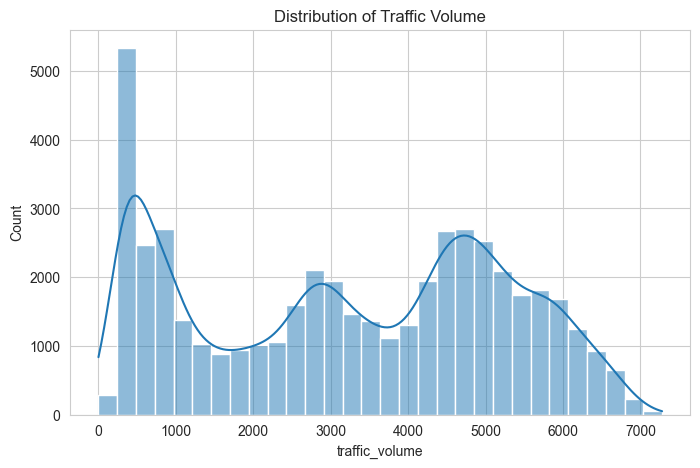

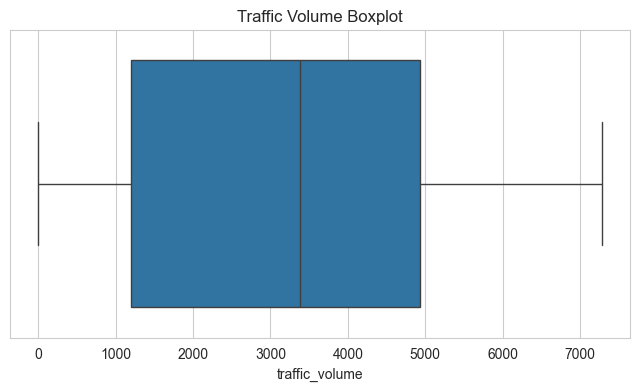

In [40]:
# TODO: Perform univariate analysis — explore distributions of individual features.

# Distribution of traffic volume
plt.figure(figsize=(8,5))
sns.histplot(df["traffic_volume"], bins=30, kde=True)
plt.title("Distribution of Traffic Volume")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df["traffic_volume"])
plt.title("Traffic Volume Boxplot")
plt.show()

In [41]:
# Convert date_time
df["date_time"] = pd.to_datetime(df["date_time"])

# Extract time features
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month

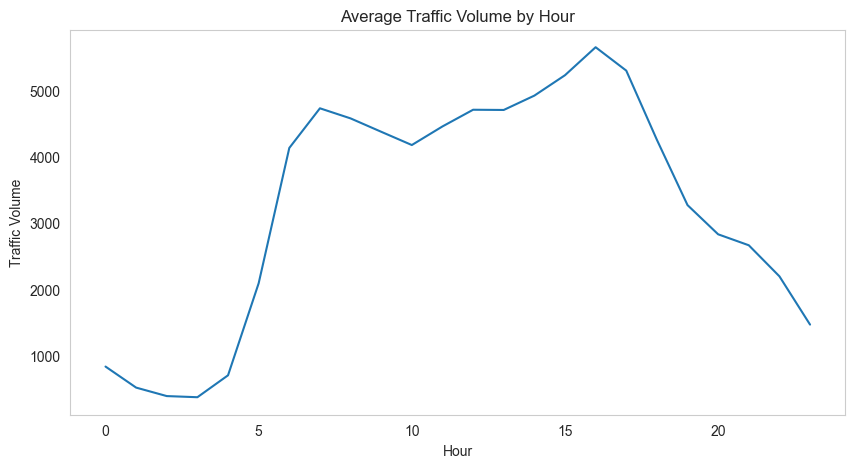

In [42]:
# Traffic by hour
hourly = df.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10,5))
hourly.plot()
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.grid()
plt.show()

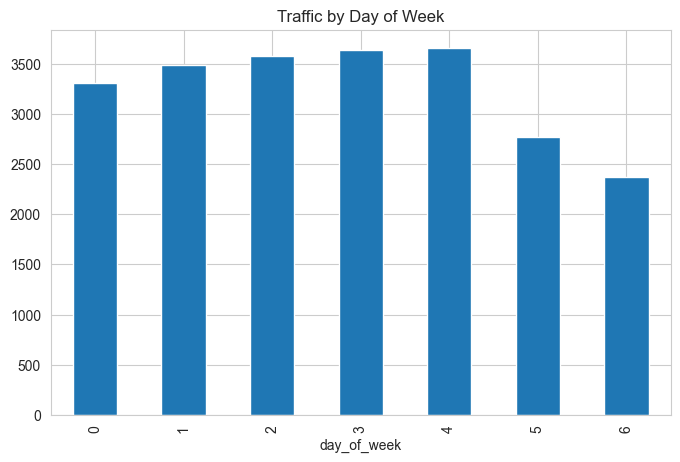

In [43]:
# Traffic by day of week
dow = df.groupby("day_of_week")["traffic_volume"].mean()

plt.figure(figsize=(8,5))
dow.plot(kind="bar")
plt.title("Traffic by Day of Week")
plt.show()

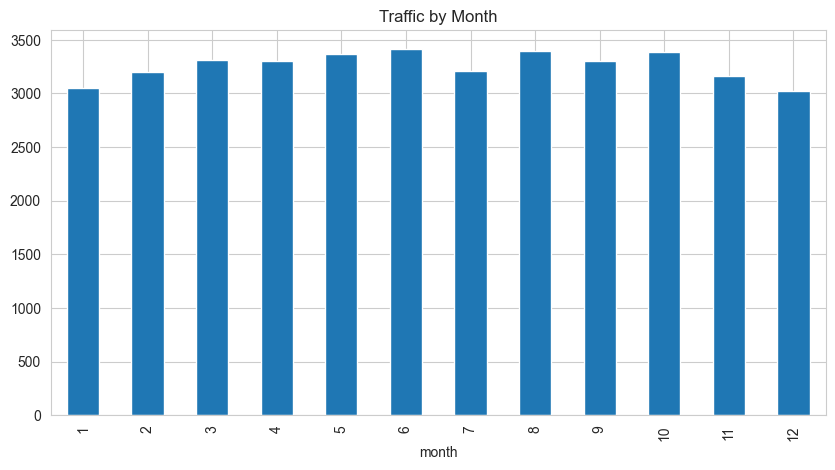

In [44]:
# Traffic by month
monthly = df.groupby("month")["traffic_volume"].mean()

plt.figure(figsize=(10,5))
monthly.plot(kind="bar")
plt.title("Traffic by Month")
plt.show()

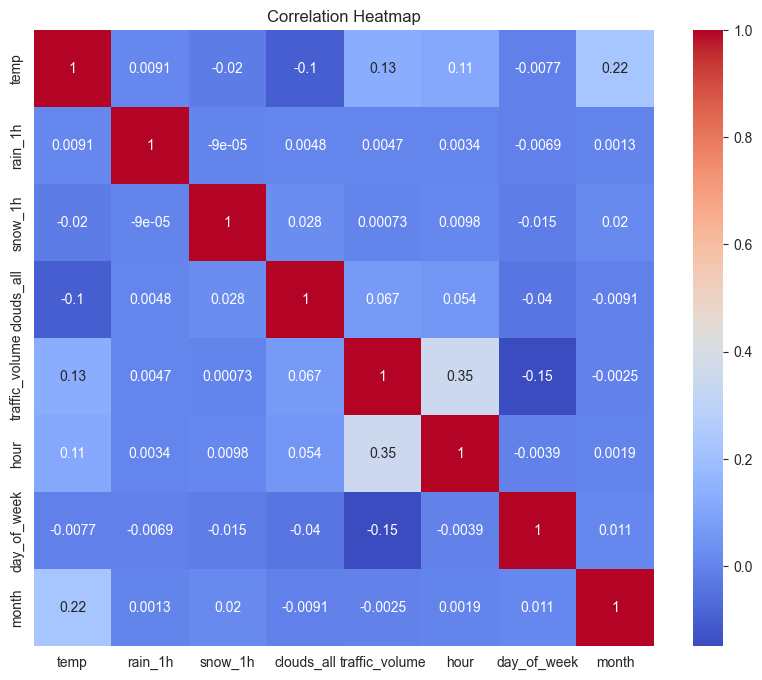

In [45]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.

plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

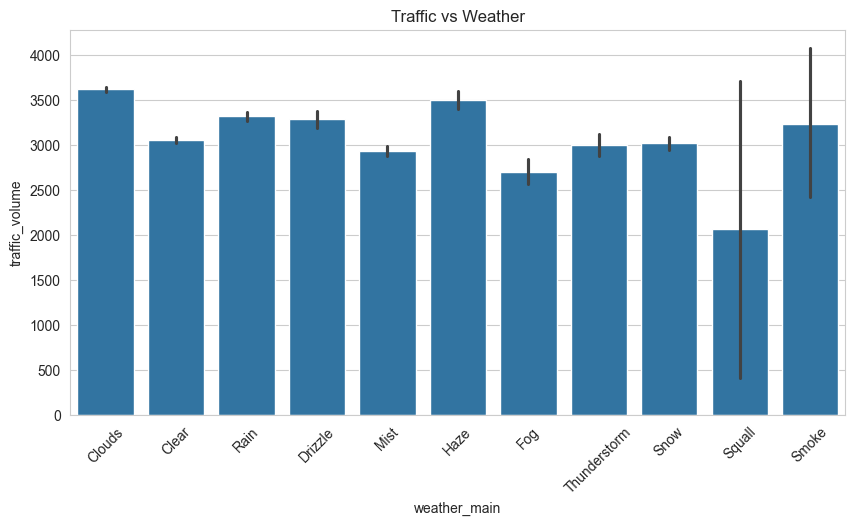

In [46]:
plt.figure(figsize=(10,5))
sns.barplot(x="weather_main", y="traffic_volume", data=df)
plt.xticks(rotation=45)
plt.title("Traffic vs Weather")
plt.show()

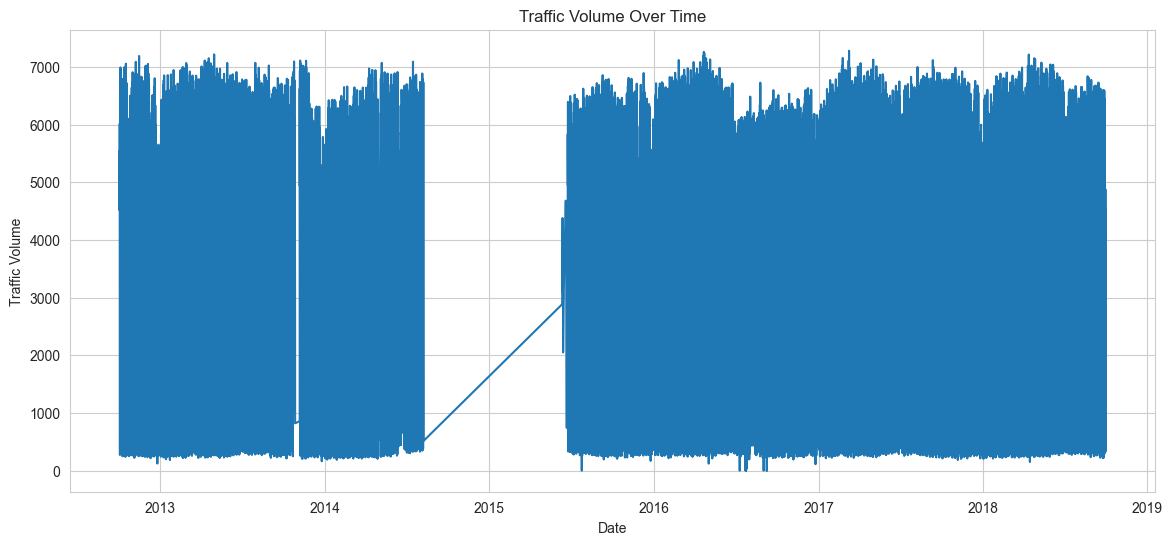

In [47]:
df = df.sort_values("date_time")

plt.figure(figsize=(14,6))
plt.plot(df["date_time"], df["traffic_volume"])
plt.title("Traffic Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.show()

In [48]:
# TODO: Document any initial insights or hypotheses from your exploration.

initial_insights = [
    "Traffic volume changes significantly across hours of the day.",
    "Weekdays have higher traffic than weekends.",
    "Seasonal trends exist across months.",
    "Weather conditions slightly affect traffic volume.",
    "Traffic data shows strong time-based patterns, making time features important."
]

for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

1. Traffic volume changes significantly across hours of the day.
2. Weekdays have higher traffic than weekends.
3. Seasonal trends exist across months.
4. Weather conditions slightly affect traffic volume.
5. Traffic data shows strong time-based patterns, making time features important.


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [49]:
# TODO: Check for missing values.

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_report = missing_report[missing_report["Missing Count"] > 0]

print(missing_report)

         Missing Count  Missing %
holiday          48143  99.873454


In [50]:
# TODO: Check for duplicate records.

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 17


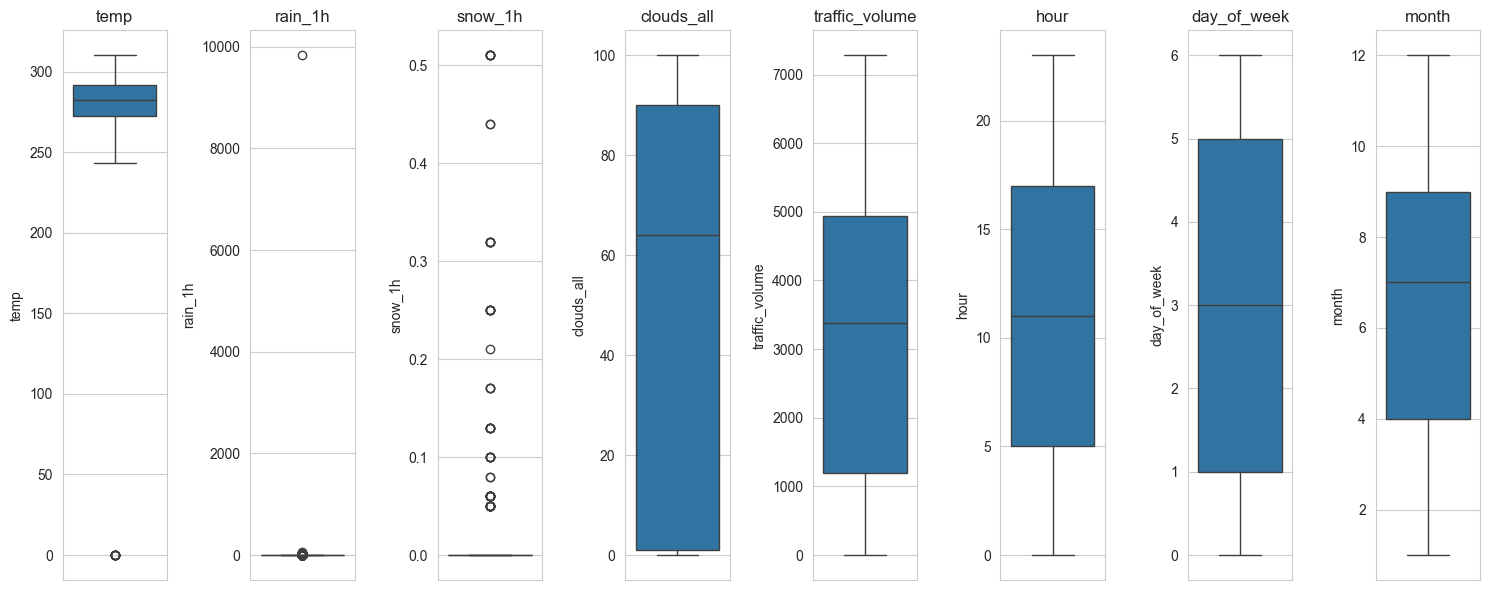

In [51]:
# TODO: Detect outliers using box plots or statistical methods.

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()